# Gut Microbiome Diversity — QC Report
#
Quality control report for the gut_microbiome_diversity curated phenotype.
#
**Generated:** 2026-02-22
**Output table:** `ds.polaris.gut_microbiome_diversity`
**Participants:** 12,302

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from databricks import sql
from dotenv import load_dotenv

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Load environment
load_dotenv()

True

In [2]:
# Connect to Databricks
connection = sql.connect(
    server_hostname=os.getenv("DATABRICKS_HOST").replace("https://", "").rstrip("/"),
    http_path=f"/sql/1.0/warehouses/{os.getenv('DATABRICKS_SQL_WAREHOUSE_ID')}",
    access_token=os.getenv("DATABRICKS_TOKEN"),
)

[WARN] pyarrow is not installed by default since databricks-sql-connector 4.0.0,any arrow specific api (e.g. fetchmany_arrow) and cloud fetch will be disabled.If you need these features, please run pip install pyarrow or pip install databricks-sql-connector[pyarrow] to install


In [3]:
# Load output data
query = "SELECT * FROM ds.polaris.gut_microbiome_diversity"
cursor = connection.cursor()
cursor.execute(query)
df = pd.DataFrame(cursor.fetchall(), columns=[desc[0] for desc in cursor.description])
cursor.close()

print(f"Loaded {len(df):,} participants from output table")
df.head()

Loaded 12,302 participants from output table


,participant_uuid,gut_microbiome_diversity__shannon_index,gut_microbiome_diversity__observed_species,gut_microbiome_diversity__diversity_category,gut_microbiome_diversity__quality_flag
0,00042acf-e5b1-47a7-a222-7bf36a2f030b,3.827752,179,Normal diversity,Adequate
1,0005230a-9749-4535-9555-430d08c16444,2.203487,114,Low diversity,Adequate
2,00094024-061a-4676-abab-d038a08b6487,3.595566,161,Normal diversity,Adequate
3,00099288-b67b-44d4-abab-aff3e7abc0fc,4.164131,248,Normal diversity,Adequate
4,0009bcb8-80ca-4eae-a666-c3a613a9e6d3,3.954148,171,Normal diversity,Adequate


## Feature Summary

In [4]:
# Basic stats
print("=" * 80)
print("FEATURE SUMMARY")
print("=" * 80)
print(f"\nTotal participants: {len(df):,}")
print(f"\nColumn names:")
for col in df.columns:
    print(f"  - {col}")

FEATURE SUMMARY

Total participants: 12,302

Column names:
  - participant_uuid
  - gut_microbiome_diversity__shannon_index
  - gut_microbiome_diversity__observed_species
  - gut_microbiome_diversity__diversity_category
  - gut_microbiome_diversity__quality_flag


In [5]:
# Shannon index statistics
shannon_col = 'gut_microbiome_diversity__shannon_index'
print(f"\n{shannon_col}:")
print(f"  Mean: {df[shannon_col].mean():.2f}")
print(f"  Median: {df[shannon_col].median():.2f}")
print(f"  Std: {df[shannon_col].std():.2f}")
print(f"  Min: {df[shannon_col].min():.2f}")
print(f"  Max: {df[shannon_col].max():.2f}")
print(f"  Missing: {df[shannon_col].isna().sum()} ({df[shannon_col].isna().sum()/len(df)*100:.1f}%)")


gut_microbiome_diversity__shannon_index:
  Mean: 3.72
  Median: 3.84
  Std: 0.60
  Min: 0.62
  Max: 4.97
  Missing: 0 (0.0%)


In [6]:
# Observed species statistics
species_col = 'gut_microbiome_diversity__observed_species'
print(f"\n{species_col}:")
print(f"  Mean: {df[species_col].mean():.1f}")
print(f"  Median: {df[species_col].median():.0f}")
print(f"  Std: {df[species_col].std():.1f}")
print(f"  Min: {df[species_col].min():.0f}")
print(f"  Max: {df[species_col].max():.0f}")
print(f"  Missing: {df[species_col].isna().sum()} ({df[species_col].isna().sum()/len(df)*100:.1f}%)")


gut_microbiome_diversity__observed_species:
  Mean: 205.2
  Median: 204
  Std: 64.3
  Min: 5
  Max: 476
  Missing: 0 (0.0%)


## Phenotype Distribution

In [7]:
# Diversity category distribution
div_cat_col = 'gut_microbiome_diversity__diversity_category'
print(f"\n{div_cat_col}:")
print(df[div_cat_col].value_counts())
print(f"\nProportions:")
print(df[div_cat_col].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))


gut_microbiome_diversity__diversity_category:
gut_microbiome_diversity__diversity_category
Normal diversity    10795
Low diversity        1507
Name: count, dtype: int64

Proportions:
gut_microbiome_diversity__diversity_category
Normal diversity    87.7%
Low diversity       12.3%
Name: proportion, dtype: object


In [8]:
# Quality flag distribution
qual_col = 'gut_microbiome_diversity__quality_flag'
print(f"\n{qual_col}:")
print(df[qual_col].value_counts())
print(f"\nProportions:")
print(df[qual_col].value_counts(normalize=True).apply(lambda x: f"{x*100:.1f}%"))


gut_microbiome_diversity__quality_flag:
gut_microbiome_diversity__quality_flag
Adequate                 12301
Low quality/dysbiotic        1
Name: count, dtype: int64

Proportions:
gut_microbiome_diversity__quality_flag
Adequate                 100.0%
Low quality/dysbiotic      0.0%
Name: proportion, dtype: object


## Visual Summaries

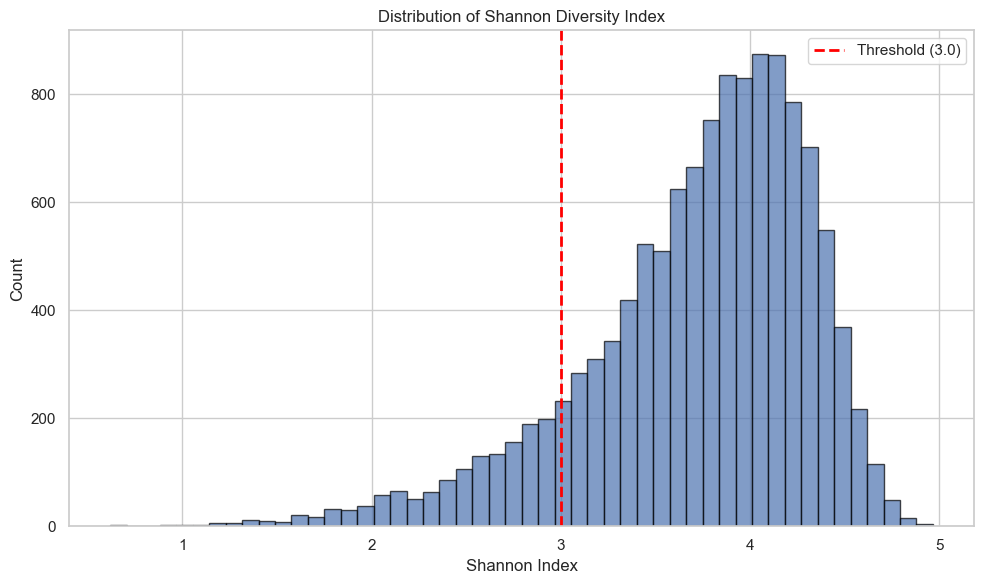

In [9]:
# Shannon index distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df[shannon_col].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax.axvline(3.0, color='red', linestyle='--', linewidth=2, label='Threshold (3.0)')
ax.set_xlabel('Shannon Index')
ax.set_ylabel('Count')
ax.set_title('Distribution of Shannon Diversity Index')
ax.legend()
plt.tight_layout()
plt.show()

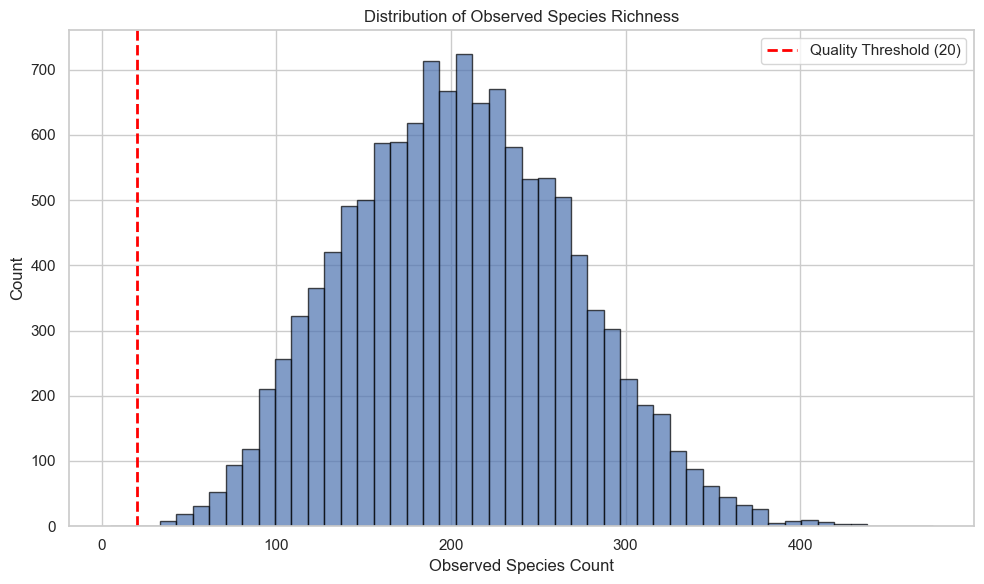

In [10]:
# Observed species distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df[species_col].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax.axvline(20, color='red', linestyle='--', linewidth=2, label='Quality Threshold (20)')
ax.set_xlabel('Observed Species Count')
ax.set_ylabel('Count')
ax.set_title('Distribution of Observed Species Richness')
ax.legend()
plt.tight_layout()
plt.show()

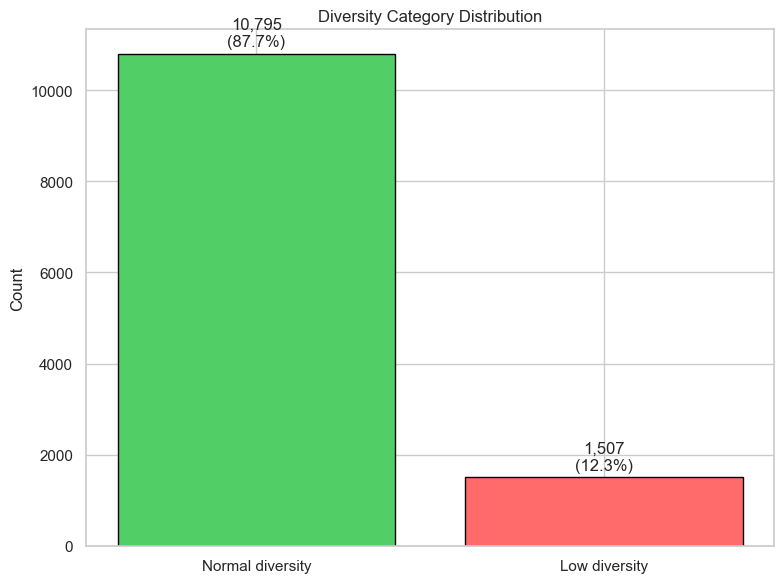

In [11]:
# Diversity category bar chart
fig, ax = plt.subplots(figsize=(8, 6))
counts = df[div_cat_col].value_counts()
colors = ['#ff6b6b' if cat == 'Low diversity' else '#51cf66' for cat in counts.index]
ax.bar(counts.index, counts.values, color=colors, edgecolor='black')
ax.set_ylabel('Count')
ax.set_title('Diversity Category Distribution')
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom')
plt.tight_layout()
plt.show()

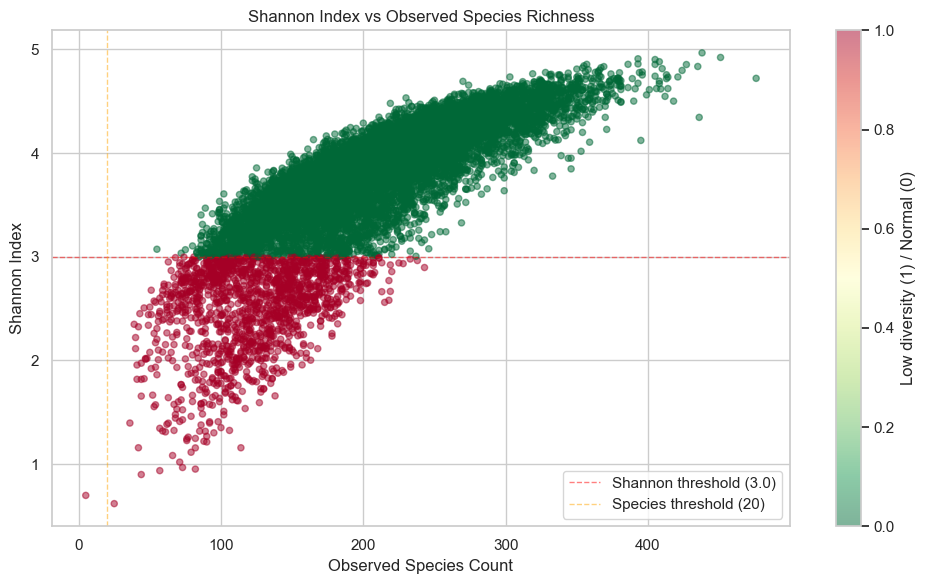

In [12]:
# Shannon index vs observed species scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df[species_col], df[shannon_col],
                     c=(df[div_cat_col] == 'Low diversity').astype(int),
                     cmap='RdYlGn_r', alpha=0.5, s=20)
ax.axhline(3.0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Shannon threshold (3.0)')
ax.axvline(20, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Species threshold (20)')
ax.set_xlabel('Observed Species Count')
ax.set_ylabel('Shannon Index')
ax.set_title('Shannon Index vs Observed Species Richness')
ax.legend()
plt.colorbar(scatter, label='Low diversity (1) / Normal (0)', ax=ax)
plt.tight_layout()
plt.show()

## Missingness Analysis

In [13]:
# Check for missing values in each column
print("=" * 80)
print("MISSINGNESS ANALYSIS")
print("=" * 80)
for col in df.columns:
    missing = df[col].isna().sum()
    print(f"{col}: {missing} ({missing/len(df)*100:.2f}%)")

MISSINGNESS ANALYSIS
participant_uuid: 0 (0.00%)
gut_microbiome_diversity__shannon_index: 0 (0.00%)
gut_microbiome_diversity__observed_species: 0 (0.00%)
gut_microbiome_diversity__diversity_category: 0 (0.00%)
gut_microbiome_diversity__quality_flag: 0 (0.00%)


## Cross-Tabulations

In [14]:
# Diversity category vs quality flag
print("\n" + "=" * 80)
print("CROSS-TABULATION: Diversity Category × Quality Flag")
print("=" * 80)
crosstab = pd.crosstab(df[div_cat_col], df[qual_col], margins=True)
print(crosstab)


CROSS-TABULATION: Diversity Category × Quality Flag
gut_microbiome_diversity__quality_flag        Adequate  Low quality/dysbiotic  \
gut_microbiome_diversity__diversity_category                                    
Low diversity                                     1506                      1   
Normal diversity                                 10795                      0   
All                                              12301                      1   

gut_microbiome_diversity__quality_flag          All  
gut_microbiome_diversity__diversity_category         
Low diversity                                  1507  
Normal diversity                              10795  
All                                           12302  


In [15]:
# Proportions within diversity categories
print("\nProportions within diversity categories:")
crosstab_pct = pd.crosstab(df[div_cat_col], df[qual_col], normalize='index')
print(crosstab_pct.apply(lambda x: x.map(lambda v: f"{v*100:.1f}%")))


Proportions within diversity categories:
gut_microbiome_diversity__quality_flag       Adequate Low quality/dysbiotic
gut_microbiome_diversity__diversity_category                               
Low diversity                                   99.9%                  0.1%
Normal diversity                               100.0%                  0.0%


## Summary Statistics Table

In [16]:
summary_stats = pd.DataFrame({
    'Feature': [
        'Total Participants',
        'Shannon Index (mean ± std)',
        'Observed Species (mean ± std)',
        'Low Diversity Count (%)',
        'Normal Diversity Count (%)',
        'Low Quality/Dysbiotic Count (%)',
        'Adequate Quality Count (%)',
    ],
    'Value': [
        f"{len(df):,}",
        f"{df[shannon_col].mean():.2f} ± {df[shannon_col].std():.2f}",
        f"{df[species_col].mean():.1f} ± {df[species_col].std():.1f}",
        f"{(df[div_cat_col]=='Low diversity').sum():,} ({(df[div_cat_col]=='Low diversity').sum()/len(df)*100:.1f}%)",
        f"{(df[div_cat_col]=='Normal diversity').sum():,} ({(df[div_cat_col]=='Normal diversity').sum()/len(df)*100:.1f}%)",
        f"{(df[qual_col]=='Low quality/dysbiotic').sum():,} ({(df[qual_col]=='Low quality/dysbiotic').sum()/len(df)*100:.1f}%)",
        f"{(df[qual_col]=='Adequate').sum():,} ({(df[qual_col]=='Adequate').sum()/len(df)*100:.1f}%)",
    ]
})
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)
print(summary_stats.to_string(index=False))


SUMMARY STATISTICS
                        Feature           Value
             Total Participants          12,302
     Shannon Index (mean ± std)     3.72 ± 0.60
  Observed Species (mean ± std)    205.2 ± 64.3
        Low Diversity Count (%)   1,507 (12.3%)
     Normal Diversity Count (%)  10,795 (87.7%)
Low Quality/Dysbiotic Count (%)        1 (0.0%)
     Adequate Quality Count (%) 12,301 (100.0%)


In [17]:
# Close connection
connection.close()
print("\n✓ QC report complete")


✓ QC report complete
